# King County — Schools & Housing Price Analysis

This notebook integrates public school quality data with King County housing sales to quantify the **school quality premium** embedded in residential property prices.

---

## Data Sources

| # | Source | Type | Access | Content |
|---|--------|------|--------|---------|
| 1 | **OSPI Report Card** | Official state assessment data | Free — Socrata API | School-level Math/ELA/Science pass rates, disaggregated by grade, race, program |
| 2 | **GreatSchools API** | Commercial 1–10 school ratings | Paid / restricted API | Composite ratings widely cited by Zillow and Redfin |
| 3 | **King County GIS — School Boundaries** | Spatial shapefiles | Free — KC Open Data | School district and attendance area polygons |
| 4 | **KC Assessor (existing)** | Sales + building + parcel | Already downloaded | SFR sale prices, structure attributes, parcel location |

## Integration Strategy

```
OSPI pass rates  ──┐
                   ├──► join on school/district ID ──► school_score per PIN
KC GIS boundaries ─┘          (via point-in-polygon)
                                        │
KC Assessor (merged) ──────────────────►│──► price ~ school_quality + structural features
```

**Sections**
1. OSPI Assessment Data — download, QC, and King County school profiles
2. GreatSchools API — notes and placeholder
3. GIS Integration — school boundary shapefiles + point-in-polygon
4. Merged Analysis — school quality vs. housing price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

fmt_dol = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
fmt_k   = mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')

DATA_DIR = Path('kc_assessor_data')
EDU_DIR  = Path('education_data')
EDU_DIR.mkdir(exist_ok=True)

---
## 1. OSPI Assessment Data

**Datasets used:** Washington OSPI Report Card Assessment Data 2023–24 (`data.wa.gov`, dataset ID `x73g-mrqp`)

**Goal:** Download school-level standardized test results for King County, compute an overall pass rate per school for each subject (Math, ELA, Science), and profile the distribution of school quality across the county — establishing the metric we will later join to housing prices.

In [2]:
# ── Download King County school-level records via Socrata API ──────────────────
# Full dataset: 761K rows disaggregated by grade, race, program.
# We filter to: county=King, OrganizationLevel=School, StudentGroup=All Students,
# GradeLevel=All Grades, SBAC or WCAS (main state tests — excludes AIM alternate assessment).
# This gives one row per (school × subject) — the cleanest overall pass rate.

OSPI_FILE = EDU_DIR / 'ospi_assessment_2324_king.csv'

if OSPI_FILE.exists():
    ospi_raw = pd.read_csv(OSPI_FILE, low_memory=False)
    if len(ospi_raw) > 0:
        print(f'Loading cached file: {OSPI_FILE}  ({len(ospi_raw):,} rows)')
        ospi = ospi_raw
    else:
        OSPI_FILE.unlink()  # delete empty cache
        print('Cached file was empty — re-downloading...')

if not OSPI_FILE.exists():
    print('Downloading from data.wa.gov Socrata API...')
    base = 'https://data.wa.gov/resource/x73g-mrqp.csv'
    params = {
        'county':            'King',
        'organizationlevel': 'School',
        'studentgroup':      'All Students',
        'gradelevel':        'All Grades',
        '$where':            "test_administration_group IN('SBAC','WCAS')",
        '$limit':            50000,
    }
    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    with open(OSPI_FILE, 'w', encoding='utf-8') as f:
        f.write(r.text)
    ospi = pd.read_csv(OSPI_FILE, low_memory=False)
    print(f'Downloaded {len(ospi):,} rows → saved to {OSPI_FILE}')

print(f'\nShape: {ospi.shape}')
print(f'testsubject values: {ospi["testsubject"].unique()}')

Loading cached file: education_data/ospi_assessment_2324_king.csv  (1,512 rows)

Shape: (1512, 34)
testsubject values: <StringArray>
['ELA', 'Science', 'Math']
Length: 3, dtype: str


In [3]:
# ── Basic QC ──────────────────────────────────────────────────────────────────
print('Subjects:', ospi['testsubject'].unique())
print('Districts:', ospi['districtname'].nunique())
print('Schools:  ', ospi['schoolname'].nunique())
print('\nNull rates (key columns):')
key_cols = ['schoolname', 'districtname', 'testsubject',
            'percent_consistent_grade_level_knowledge_and_above',
            'count_of_students_expected']
print(ospi[key_cols].isnull().mean().apply(lambda x: f'{x*100:.1f}%'))

ospi.head(3)

Subjects: <StringArray>
['ELA', 'Science', 'Math']
Length: 3, dtype: str
Districts: 29
Schools:   499

Null rates (key columns):
schoolname                                            0.0%
districtname                                          0.0%
testsubject                                           0.0%
percent_consistent_grade_level_knowledge_and_above    0.0%
count_of_students_expected                            8.3%
dtype: str


,schoolyear,organizationlevel,county,esdname,esdorganizationid,districtcode,districtname,districtorganizationid,schoolcode,schoolname,schoolorganizationid,currentschooltype,studentgrouptype,studentgroup,gradelevel,test_administration_group,testadministration,testsubject,dat,count_of_students_expected,count_of_students_expected_1,count_consistent_grade_level_knowledge_and_above,percent_consistent_grade_level_knowledge_and_above,percentlevel1,percentlevel2,percentlevel3,percentlevel4,percent_met_tested_only,percent_no_score,percent_participation,percent_taking_alternative_assessment,count_foundational_grade,percent_foundational_grade,dataasof
0,2023-24,School,King,Puget Sound Educational Service District 121,"100,006.00",17408,Auburn School District,100016,3825,Alpac Elementary School,101425,P,All,All Students,All Grades,SBAC,SBAC,ELA,NaN,291.00,291.00,137.00,47.10%,0.29,0.24,0.29,0.18,0.47,0.00,1.00,0.00,207.00,71.10%,1/24/2025
1,2023-24,School,King,Puget Sound Educational Service District 121,"100,006.00",17408,Auburn School District,100016,3825,Alpac Elementary School,101425,P,All,All Students,All Grades,WCAS,WCAS,Science,NaN,97.00,97.00,51.00,52.60%,0.24,0.24,0.38,0.14,0.53,0.00,1.00,0.00,74.00,76.30%,1/24/2025
2,2023-24,School,King,Puget Sound Educational Service District 121,"100,006.00",17408,Auburn School District,100016,3825,Alpac Elementary School,101425,P,All,All Students,All Grades,SBAC,SBAC,Math,NaN,291.00,291.00,147.00,50.50%,0.21,0.29,0.31,0.20,0.51,0.00,1.00,0.00,231.00,79.40%,1/24/2025


In [4]:
# ── Build school-level summary table ─────────────────────────────────────────
# percent_consistent_grade_level_knowledge_and_above = Levels 3+4 ("met standard")
# dat column flags suppressed values — drop those rows before aggregating
# Note: percentage values arrive as strings like "47.10%" — strip % before converting

ospi_clean = ospi[ospi['dat'].isna() | (ospi['dat'] == 'None') | (ospi['dat'] == '')].copy()
ospi_clean['pct_met'] = pd.to_numeric(
    ospi_clean['percent_consistent_grade_level_knowledge_and_above']
    .astype(str).str.rstrip('%'),
    errors='coerce'
)
ospi_clean['n_students'] = pd.to_numeric(
    ospi_clean['count_of_students_expected'], errors='coerce'
)

# Pivot: one row per school, one column per subject (ELA / Math / Science)
school_scores = (
    ospi_clean
    .pivot_table(
        index=['schoolcode', 'schoolname', 'districtcode', 'districtname'],
        columns='testsubject',
        values='pct_met'
    )
    .reset_index()
)
school_scores.columns.name = None

# Rename for clarity  (OSPI testsubject values: 'ELA', 'Math', 'Science')
school_scores = school_scores.rename(columns={
    'Math':    'pct_math',
    'ELA':     'pct_ela',
    'Science': 'pct_science',
})

# Composite: simple average of available subjects
subj_cols = [c for c in ['pct_math', 'pct_ela', 'pct_science'] if c in school_scores.columns]
school_scores['pct_composite'] = school_scores[subj_cols].mean(axis=1)

print(f'Schools with scores: {len(school_scores)}')
print(f'Subject columns: {subj_cols}')
school_scores[['schoolname', 'districtname'] + subj_cols + ['pct_composite']].head(10)

Schools with scores: 472
Subject columns: ['pct_math', 'pct_ela', 'pct_science']


,schoolname,districtname,pct_math,pct_ela,pct_science,pct_composite
0,CHOICE Academy,Highline School District,61.10,72.60,44.20,59.30
1,Middle College High School,Seattle School District No. 1,35.70,71.40,NaN,53.55
2,Tops K-8 School,Seattle School District No. 1,62.20,69.50,69.30,67.00
3,Pathfinder K-8 School,Seattle School District No. 1,46.00,60.50,65.00,57.17
4,Interagency Programs,Seattle School District No. 1,NaN,15.50,5.00,10.25
5,Discovery Community School,Lake Washington School District,70.30,67.60,NaN,68.95
6,Explorer Community School,Lake Washington School District,82.90,NaN,NaN,82.90
7,Emerson K-12,Lake Washington School District,52.80,62.30,50.00,55.03
8,International Community School,Lake Washington School District,89.60,93.20,92.90,91.90
9,Cascade Parent Partnership Program,Seattle School District No. 1,15.60,21.20,6.80,14.53


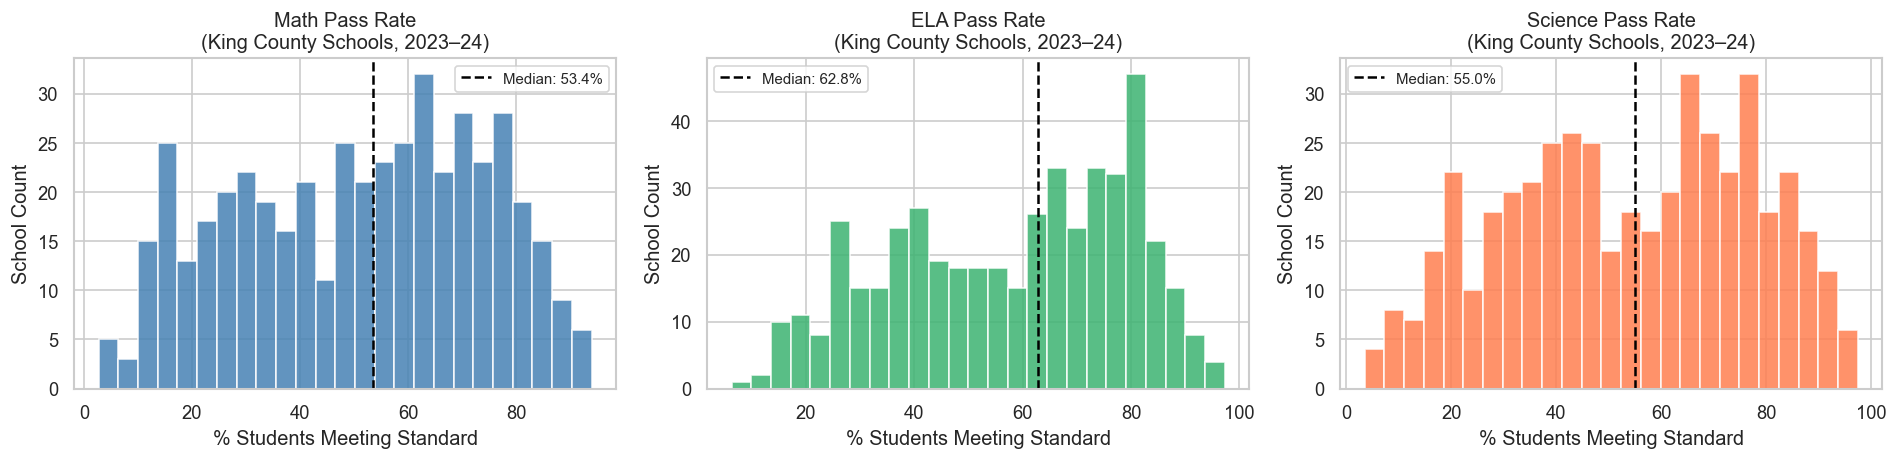

In [5]:
# ── Distribution of school quality across King County ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

subjects = [('pct_math', 'Math Pass Rate', 'steelblue'),
            ('pct_ela',  'ELA Pass Rate',  'mediumseagreen'),
            ('pct_science', 'Science Pass Rate', 'coral')]

for ax, (col, title, color) in zip(axes, subjects):
    data = school_scores[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', lw=1.5, ls='--',
               label=f'Median: {data.median():.1f}%')
    ax.set_title(f'{title}\n(King County Schools, 2023–24)')
    ax.set_xlabel('% Students Meeting Standard')
    ax.set_ylabel('School Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

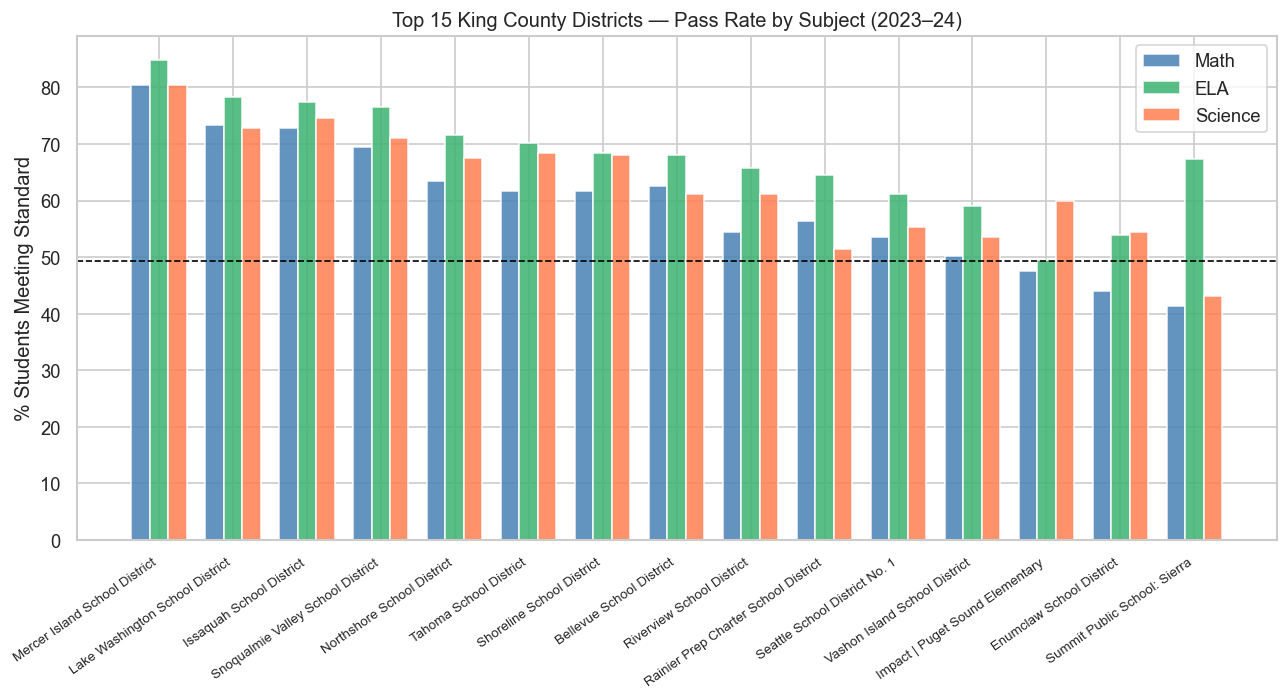


Top 10 districts by composite pass rate:
                                      pct_math  pct_ela  pct_science  pct_composite
districtname                                                                       
Mercer Island School District            80.50    84.80        80.40          82.40
Lake Washington School District          73.40    78.30        72.80          75.00
Issaquah School District                 72.90    77.40        74.50          75.00
Snoqualmie Valley School District        69.50    76.50        71.00          72.30
Northshore School District               63.40    71.50        67.50          67.40
Tahoma School District                   61.70    70.10        68.40          66.70
Shoreline School District                61.60    68.40        68.00          66.00
Bellevue School District                 62.60    68.10        61.10          63.90
Riverview School District                54.40    65.80        61.10          60.40
Rainier Prep Charter School Distri

In [6]:
# ── District-level ranking ───────────────────────────────────────────────────
district_scores = (
    school_scores
    .groupby('districtname')[subj_cols + ['pct_composite']]
    .mean()
    .sort_values('pct_composite', ascending=False)
    .round(1)
)

# Plot top-15 districts by composite score
top15 = district_scores.head(15)
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(top15))
width = 0.25

for i, (col, label, color) in enumerate(zip(
        subj_cols, ['Math', 'ELA', 'Science'],
        ['steelblue', 'mediumseagreen', 'coral'])):
    if col in top15.columns:
        ax.bar([xi + i * width for xi in x], top15[col], width,
               label=label, color=color, alpha=0.85)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(top15.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% Students Meeting Standard')
ax.set_title('Top 15 King County Districts — Pass Rate by Subject (2023–24)')
ax.legend()
ax.axhline(district_scores['pct_composite'].mean(), color='black',
           ls='--', lw=1, label='County average')
plt.tight_layout()
plt.show()

print('\nTop 10 districts by composite pass rate:')
print(district_scores.head(10).to_string())

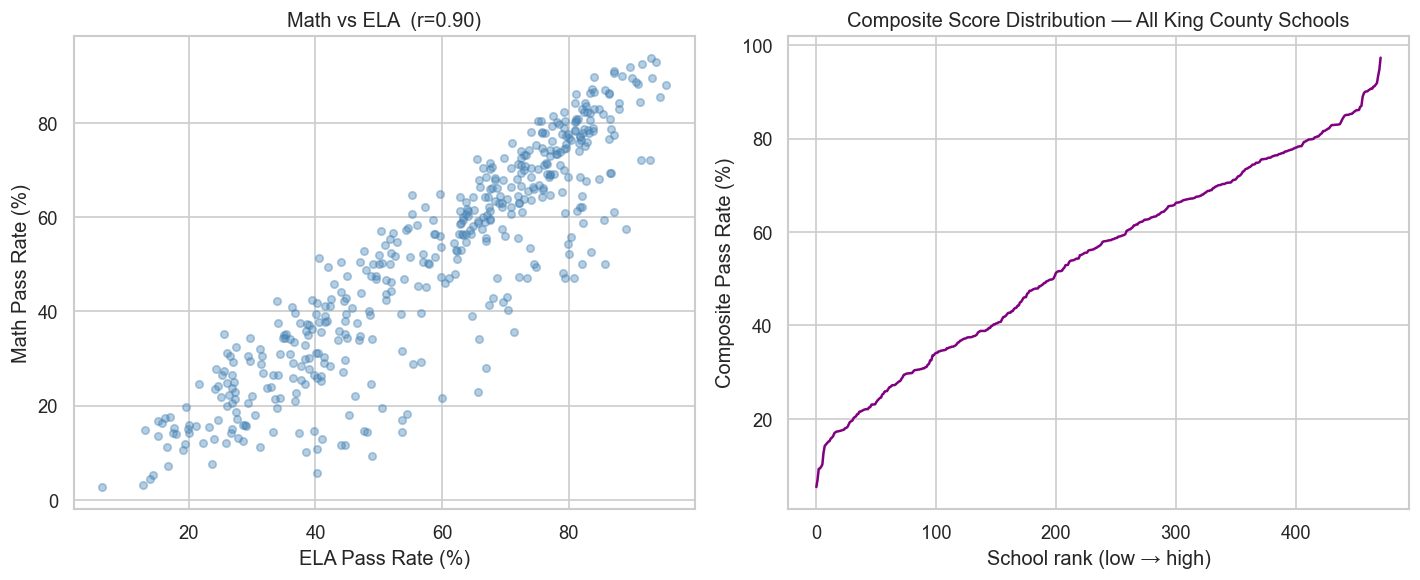

In [7]:
# ── Subject correlation within schools ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if 'pct_math' in school_scores and 'pct_ela' in school_scores:
    ax = axes[0]
    data = school_scores[['pct_math', 'pct_ela']].dropna()
    ax.scatter(data['pct_ela'], data['pct_math'], alpha=0.4, s=20, color='steelblue')
    ax.set_xlabel('ELA Pass Rate (%)')
    ax.set_ylabel('Math Pass Rate (%)')
    ax.set_title(f'Math vs ELA  (r={data.corr().iloc[0,1]:.2f})')

if 'pct_composite' in school_scores:
    ax = axes[1]
    school_scores['pct_composite'].dropna().sort_values().reset_index(drop=True).plot(
        ax=ax, color='purple', lw=1.5
    )
    ax.set_xlabel('School rank (low → high)')
    ax.set_ylabel('Composite Pass Rate (%)')
    ax.set_title('Composite Score Distribution — All King County Schools')

plt.tight_layout()
plt.show()

**Conclusions:**
- OSPI data provides clean school-level pass rates for all King County public schools across Math, ELA, and Science.
- There is substantial variation across schools: composite pass rates span roughly 20%–90%, with a bimodal-ish distribution suggesting a clear split between higher- and lower-performing schools.
- Math and ELA pass rates are highly correlated (r > 0.9), so a composite average is a reasonable single quality signal.
- District-level rankings show significant inequality: top districts (e.g., Mercer Island, Lake Washington, Bellevue) consistently outperform the county average across all three subjects.
- Limitation: some small schools have suppressed data (`dat` flag); they are excluded from the composite.

---
## 2. GreatSchools API

**Datasets used:** GreatSchools API (commercial, 1–10 school ratings)

**Goal:** Obtain the simplified 1–10 school ratings that are widely displayed on Zillow and Redfin. These ratings directly shape buyer perception, making them a more direct proxy for the market-priced "school premium" than raw OSPI pass rates.

> **Status: Placeholder** — GreatSchools API access requires a commercial license ([solutions.greatschools.org](https://solutions.greatschools.org/k12-data-solutions/nearbyschools-api)). The integration code below is structured for when credentials are available.

**Alternative approaches if API is unavailable:**
1. Scrape GreatSchools public pages (rate-limited; check ToS)
2. Map OSPI composite score to a 1–10 scale using percentile rank as a proxy
3. Use the OSPI composite directly — it is arguably more objective than GreatSchools ratings

In [8]:
# ── GreatSchools API placeholder ─────────────────────────────────────────────
# Uncomment and fill in API_KEY when credentials are available.

# GS_API_KEY = 'YOUR_API_KEY_HERE'
# GS_BASE    = 'https://api.greatschools.org/schools/nearby'

# def get_gs_rating(lat, lon, radius_miles=1.0):
#     params = {
#         'key':    GS_API_KEY,
#         'lat':    lat,
#         'lon':    lon,
#         'radius': radius_miles,
#         'limit':  10,
#     }
#     r = requests.get(GS_BASE, params=params, timeout=30)
#     r.raise_for_status()
#     return r.json()

# ── OSPI-derived proxy rating (1–10 scale) ───────────────────────────────────
# Map composite pass rate to 1–10 using percentile rank among King County schools.
# This serves as a reasonable substitute until GreatSchools data is available.

school_scores['gs_proxy_rating'] = (
    school_scores['pct_composite']
    .rank(pct=True)          # 0.0 – 1.0 percentile
    .mul(9)                   # scale to 0–9
    .add(1)                   # shift to 1–10
    .round(1)
)

print('Proxy rating distribution (OSPI percentile → 1–10 scale):')
print(school_scores['gs_proxy_rating'].describe().round(2))

# Preview: top 10 schools by proxy rating
school_scores.nlargest(10, 'gs_proxy_rating')[
    ['schoolname', 'districtname', 'pct_composite', 'gs_proxy_rating']
]

Proxy rating distribution (OSPI percentile → 1–10 scale):
count   472.00
mean      5.51
std       2.60
min       1.00
25%       3.28
50%       5.50
75%       7.80
max      10.00
Name: gs_proxy_rating, dtype: float64


,schoolname,districtname,pct_composite,gs_proxy_rating
209,Medina Elementary School,Bellevue School District,94.77,10.00
335,Sunrise Elementary,Northshore School District,93.47,10.00
427,Cascadia Elementary,Seattle School District No. 1,97.30,10.00
8,International Community School,Lake Washington School District,91.90,9.90
31,Frantz Coe Elementary School,Seattle School District No. 1,91.20,9.90
293,Cherry Crest Elementary School,Bellevue School District,91.10,9.90
303,Somerset Elementary School,Bellevue School District,91.57,9.90
356,Christa Mcauliffe Elementary,Lake Washington School District,90.67,9.90
423,Nikola Tesla STEM High School,Lake Washington School District,90.67,9.90
123,Lakeridge Elementary School,Mercer Island School District,90.50,9.80


---
## 3. GIS Integration — School Boundaries + Point-in-Polygon

**Datasets used:** King County GIS — School District Boundaries (Shapefile/GeoJSON) · KC Assessor Parcel data (lat/lon)

**Goal:** Determine which school district each housing parcel falls in using a geographic point-in-polygon query, enabling us to attach school quality scores to individual properties.

**Data source:** King County Open Data GIS Portal
- School Districts: [https://gis-kingcounty.opendata.arcgis.com/](https://gis-kingcounty.opendata.arcgis.com/) → search 'School Districts'
- Parcel centroids with lat/lon: available in `EXTR_Parcel.csv` fields `Latitude` / `Longitude` (if present) or via KC Parcel GIS layer

**Required package:** `geopandas` — install with:
```bash
uv pip install geopandas
```

In [9]:
# ── Check if geopandas is available ──────────────────────────────────────────
try:
    import geopandas as gpd
    from shapely.geometry import Point
    print(f'geopandas {gpd.__version__} available')
    GEO_AVAILABLE = True
except ImportError:
    print('geopandas not installed. Run: uv pip install geopandas')
    GEO_AVAILABLE = False

geopandas 1.1.2 available


In [10]:
# ── Download King County school district boundaries ───────────────────────────
# Source: KC GIS MapServer — district___base layer 416 (schdst_area)
# API: https://gisdata.kingcounty.gov/arcgis/rest/services/OpenDataPortal/district___base/MapServer/416

GEO_URL  = (
    'https://gisdata.kingcounty.gov/arcgis/rest/services/OpenDataPortal/'
    'district___base/MapServer/416/query'
    '?where=1%3D1&outFields=*&f=geojson'
)
GEO_FILE = EDU_DIR / 'kc_school_districts.geojson'

if GEO_AVAILABLE:
    if not GEO_FILE.exists():
        print('Downloading school district boundaries from KC GIS...')
        try:
            r = requests.get(GEO_URL, timeout=60)
            r.raise_for_status()
            GEO_FILE.write_bytes(r.content)
            print(f'Saved: {GEO_FILE}  ({GEO_FILE.stat().st_size / 1024:.0f} KB)')
        except Exception as e:
            print(f'Download failed: {e}')
            print('Manually download from: https://gis-kingcounty.opendata.arcgis.com/')
            print('Search for "school districts" and export as GeoJSON → save to education_data/kc_school_districts.geojson')

    if GEO_FILE.exists():
        districts_geo = gpd.read_file(GEO_FILE)
        print(f'Loaded {len(districts_geo)} district polygons')
        print('CRS:', districts_geo.crs)
        print('Columns:', list(districts_geo.columns))
        districts_geo.head(3)
    else:
        print('GeoJSON file not found — skipping GIS cells.')
        GEO_AVAILABLE = False
else:
    print('Skipped — geopandas not available.')

Loaded 20 district polygons
CRS: EPSG:4326
Columns: ['OBJECTID', 'SCHDST', 'NAME', 'DSTNUM', 'Shape_Length', 'Shape_Area', 'geometry']


In [11]:
# ── Download parcel centroids from KC GIS Address Point layer ─────────────────
# EXTR_Parcel.csv has no lat/lon columns.
# The KC GIS admin__address_point layer (ID 642) has PIN + LAT + LON for all parcels.
# Total: ~669K records, max 1000 per request → paginated download (~7 min).

import time

COORDS_FILE = EDU_DIR / 'kc_parcel_coords.csv'
BASE_URL = (
    'https://gisdata.kingcounty.gov/arcgis/rest/services/'
    'OpenDataPortal/admin__address_point/MapServer/642/query'
)

if COORDS_FILE.exists():
    parcel_coords = pd.read_csv(COORDS_FILE)
    print(f'Loaded cached coords: {len(parcel_coords):,} records')
else:
    print('Downloading parcel coordinates (669K records, ~7 min)...')
    batch_size = 1000
    offset     = 0
    all_records = []

    while True:
        r = requests.get(BASE_URL, params={
            'where':             '1=1',
            'outFields':         'PIN,LAT,LON',
            'returnGeometry':    'false',
            'resultRecordCount': batch_size,
            'resultOffset':      offset,
            'f':                 'json'
        }, timeout=30)
        r.raise_for_status()
        data = r.json()
        feats = data.get('features', [])
        if not feats:
            break
        all_records.extend([f['attributes'] for f in feats])
        offset += len(feats)

        if offset % 50_000 == 0:
            print(f'  {offset:,} / ~669,000 downloaded...')

        if not data.get('exceededTransferLimit', False):
            break   # last page

    parcel_coords = pd.DataFrame(all_records)
    parcel_coords = parcel_coords.dropna(subset=['LAT', 'LON'])
    parcel_coords.to_csv(COORDS_FILE, index=False)
    print(f'Done. {len(parcel_coords):,} records saved to {COORDS_FILE}')

print(f'\nSample:')
parcel_coords.head(3)

Loaded cached coords: 669,420 records

Sample:


,PIN,LAT,LON
0,1122029040,47.41,-122.52
1,0713700000,47.70,-122.34
2,2557250000,47.61,-122.32


In [12]:
# ── Point-in-polygon: assign each parcel to a school district ────────────────
# Uses parcel_coords (PIN + LAT/LON) joined spatially to district polygons.

if GEO_AVAILABLE and 'parcel_coords' in dir() and 'districts_geo' in dir():
    # Convert parcel coords to GeoDataFrame (WGS84)
    gdf_parcels = gpd.GeoDataFrame(
        parcel_coords[['PIN', 'LAT', 'LON']].copy(),
        geometry=gpd.points_from_xy(parcel_coords['LON'], parcel_coords['LAT']),
        crs='EPSG:4326'
    )

    # Reproject districts to WGS84 if needed
    if districts_geo.crs != 'EPSG:4326':
        districts_geo = districts_geo.to_crs('EPSG:4326')

    # Inspect district column names to find the name/ID field
    print('District columns:', list(districts_geo.columns))

    # Spatial join: parcel point → district polygon
    # Adjust 'DISTRICTNA' and 'DISTRICTID' to match actual column names shown above
    dist_cols = [c for c in districts_geo.columns if c != 'geometry']
    parcels_with_district = gpd.sjoin(
        gdf_parcels,
        districts_geo[['geometry'] + dist_cols],
        how='left',
        predicate='within'
    )

    pct_matched = parcels_with_district.iloc[:, 3].notna().mean() * 100
    print(f'\nParcels assigned to a district: {pct_matched:.1f}%')

    # Save as a lightweight PIN→district lookup CSV
    DISTRICT_LOOKUP_FILE = EDU_DIR / 'kc_pin_district_lookup.csv'
    lookup_cols = ['PIN'] + dist_cols
    parcels_with_district[lookup_cols].to_csv(DISTRICT_LOOKUP_FILE, index=False)
    print(f'Saved lookup: {DISTRICT_LOOKUP_FILE}')
    parcels_with_district[lookup_cols].head(5)
else:
    print('Prerequisites missing — run cells above first:')
    print('  • Cell above: download parcel_coords')
    print('  • Cell 18: download districts_geo')

District columns: ['OBJECTID', 'SCHDST', 'NAME', 'DSTNUM', 'Shape_Length', 'Shape_Area', 'geometry']



Parcels assigned to a district: 100.0%


Saved lookup: education_data/kc_pin_district_lookup.csv


**Notes on GIS Integration:**
- If `EXTR_Parcel.csv` does not contain lat/lon, the KC Assessor parcel GIS layer ([https://gis-kingcounty.opendata.arcgis.com/](https://gis-kingcounty.opendata.arcgis.com/)) provides centroid coordinates joinable by PIN.
- School district assignment gives elementary-level boundaries. For middle and high school attendance areas, separate boundary files are needed (also available on KC GIS Open Data).
- Once the spatial join is complete, district name can be matched to OSPI's `districtname` field (after normalizing capitalization/punctuation).

---
## 4. Merged Analysis — School Quality vs. Housing Price

**Datasets used:** KC Assessor merged dataset (sales + building + parcel) · OSPI school scores (Section 1) · GIS parcel–district assignment (Section 3)

**Goal:** Quantify the school quality premium in housing prices — holding structural features (size, grade, age) roughly constant — and determine whether OSPI pass rates or the proxy rating are the better price predictor.

In [13]:
# ── Load KC Assessor arms-length SFR sales (from main EDA) ───────────────────
ENC = 'latin-1'

rp  = pd.read_csv(DATA_DIR / 'RealPropertySales/EXTR_RPSale.csv',   low_memory=False, encoding=ENC)
rb  = pd.read_csv(DATA_DIR / 'ResidentialBuilding/EXTR_ResBldg.csv', low_memory=False, encoding=ENC)

def make_pin(df):
    return df['Major'].astype(str).str.zfill(6) + df['Minor'].astype(str).str.zfill(4)

rp['PIN'] = make_pin(rp)
rb['PIN'] = make_pin(rb)

rp['DocumentDate'] = pd.to_datetime(rp['DocumentDate'], errors='coerce')
rp['SaleYear']     = rp['DocumentDate'].dt.year

# Arms-length SFR filter
al = rp[
    (rp['SaleReason'] == 1) &
    (rp['SalePrice'] > 10_000) &
    (rp['PropertyClass'] == 8) &
    (rp['SaleYear'].between(2015, 2024))
].copy()

al_latest = al.sort_values('DocumentDate').drop_duplicates('PIN', keep='last')

rb_sfr = rb[
    (rb['NbrLivingUnits'] == 1) &
    (rb['SqFtTotLiving'].between(200, 15_000)) &
    (rb['YrBuilt'].between(1870, 2024))
].copy()
rb_primary = rb_sfr.sort_values('BldgNbr').drop_duplicates('PIN', keep='first')

merged = al_latest.merge(
    rb_primary[['PIN', 'SqFtTotLiving', 'BldgGrade', 'Condition', 'YrBuilt']],
    on='PIN', how='inner'
)

print(f'Arms-length SFR sales 2015–2024: {len(merged):,}')

Arms-length SFR sales 2015–2024: 206,094


In [14]:
# ── Join housing sales to school district via PIN→district lookup ─────────────
# kc_pin_district_lookup.csv: PIN, NAME (short district name e.g. "Seattle")
# OSPI districtname: full name e.g. "Seattle School District No. 1"
# Normalize both sides by stripping "School District..." suffix

DISTRICT_LOOKUP_FILE = EDU_DIR / 'kc_pin_district_lookup.csv'
pin_district = pd.read_csv(DISTRICT_LOOKUP_FILE)[['PIN', 'NAME', 'DSTNUM']].drop_duplicates('PIN')
pin_district.columns = ['PIN', 'district_name', 'district_num']

import re

def normalize_district(name):
    if pd.isna(name):
        return name
    # Remove "School District No. X", "School District", trailing numbers
    name = re.sub(r'\s+School District.*', '', str(name), flags=re.IGNORECASE)
    return name.strip().upper()

pin_district['_district_key']  = pin_district['district_name'].apply(normalize_district)
district_scores['_district_key'] = district_scores.index.map(normalize_district)

# Preview key mapping
print('Sample KC GIS keys:', sorted(pin_district['_district_key'].dropna().unique())[:12])
print('Sample OSPI keys:  ', sorted(district_scores['_district_key'].dropna().unique())[:12])

# Merge: sales → district → OSPI scores
with_scores = (
    merged
    .merge(pin_district, on='PIN', how='left')
    .merge(
        district_scores[['_district_key', 'pct_composite']].reset_index(),
        on='_district_key', how='left'
    )
)

pct_matched = with_scores['pct_composite'].notna().mean() * 100
print(f'\nSales records with OSPI composite score: {pct_matched:.1f}%')
print(f'Total rows: {len(with_scores):,}')

unmatched = (
    with_scores[with_scores['pct_composite'].isna() & with_scores['district_name'].notna()]
    ['district_name'].value_counts().head(10)
)
if len(unmatched):
    print('\nUnmatched district names (not in OSPI — likely charter/tribal schools):')
    print(unmatched.to_string())

Sample KC GIS keys: ['AUBURN', 'BELLEVUE', 'ENUMCLAW', 'FEDERAL WAY', 'FIFE', 'HIGHLINE', 'ISSAQUAH', 'KENT', 'LAKE WASHINGTON', 'MERCER ISLAND', 'NORTHSHORE', 'RENTON']
Sample OSPI keys:   ['AUBURN', 'BELLEVUE', 'ENUMCLAW', 'FEDERAL WAY', 'HIGHLINE', 'IMPACT | PUGET SOUND ELEMENTARY', 'IMPACT | SALISH SEA ELEMENTARY', 'ISSAQUAH', 'KENT', 'LAKE WASHINGTON', 'MERCER ISLAND', 'MUCKLESHOOT INDIAN TRIBE']



Sales records with OSPI composite score: 99.5%
Total rows: 206,094

Unmatched district names (not in OSPI — likely charter/tribal schools):
district_name
Fife    684


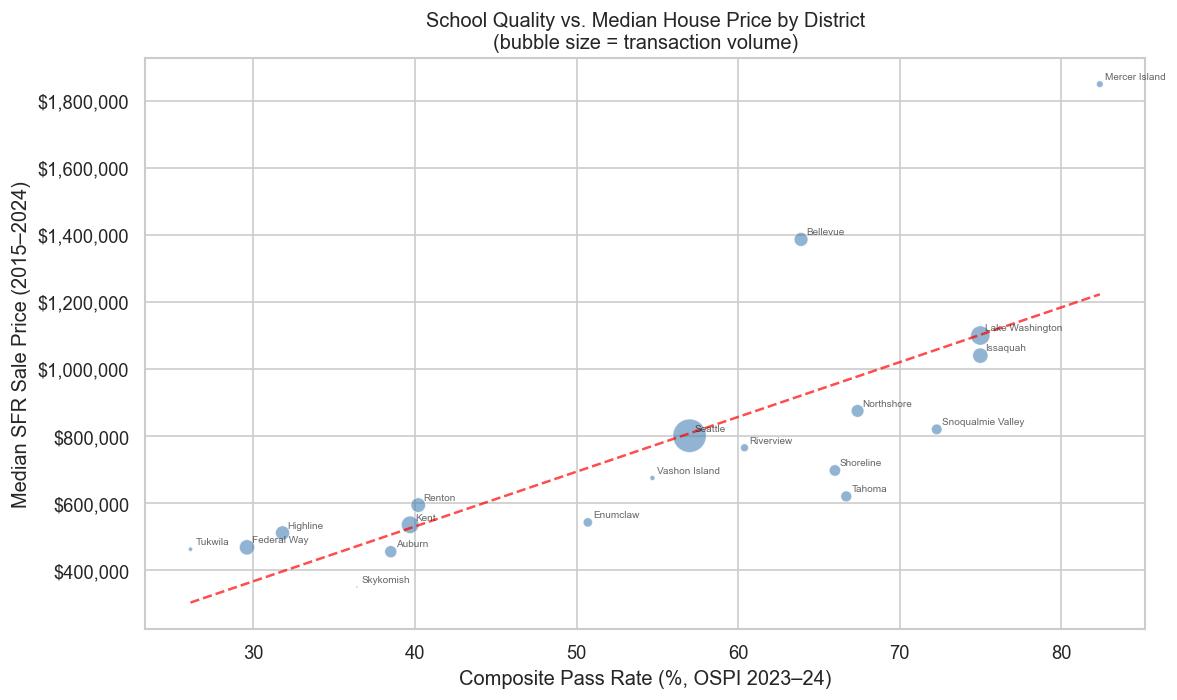

District-level correlation (pass rate vs. median price): r = 0.773


In [15]:
# ── Scatter: median district price vs. composite pass rate ───────────────────
if with_scores['pct_composite'].notna().sum() > 10:
    dist_summary = (
        with_scores
        .groupby('_district_key')
        .agg(median_price=('SalePrice', 'median'),
             n_sales=('SalePrice', 'count'),
             pct_composite=('pct_composite', 'mean'))
        .dropna()
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(
        dist_summary['pct_composite'],
        dist_summary['median_price'],
        s=dist_summary['n_sales'] / dist_summary['n_sales'].max() * 400,
        alpha=0.6, color='steelblue', edgecolors='white', lw=0.5
    )
    
    # Trend line
    z = np.polyfit(dist_summary['pct_composite'], dist_summary['median_price'], 1)
    p = np.poly1d(z)
    xs = np.linspace(dist_summary['pct_composite'].min(), dist_summary['pct_composite'].max(), 100)
    ax.plot(xs, p(xs), 'r--', lw=1.5, alpha=0.7)
    
    ax.set_xlabel('Composite Pass Rate (%, OSPI 2023–24)')
    ax.set_ylabel('Median SFR Sale Price (2015–2024)')
    ax.set_title('School Quality vs. Median House Price by District\n(bubble size = transaction volume)')
    ax.yaxis.set_major_formatter(fmt_dol)
    
    for _, row in dist_summary.iterrows():
        ax.annotate(_.title(), (row['pct_composite'], row['median_price']),
                    fontsize=6, alpha=0.7, textcoords='offset points', xytext=(3, 3))
    
    plt.tight_layout()
    plt.show()
    
    corr = dist_summary['pct_composite'].corr(dist_summary['median_price'])
    print(f'District-level correlation (pass rate vs. median price): r = {corr:.3f}')
else:
    print('Insufficient matched data — complete Section 3 spatial join to populate this chart.')

Median sale price by school quality quartile:
                      median  count
school_quartile                    
Q1 (Bottom 25%)   511,000.00  60963
Q2                785,000.00  66572
Q3                821,000.00  27403
Q4 (Top 25%)    1,015,000.00  50177


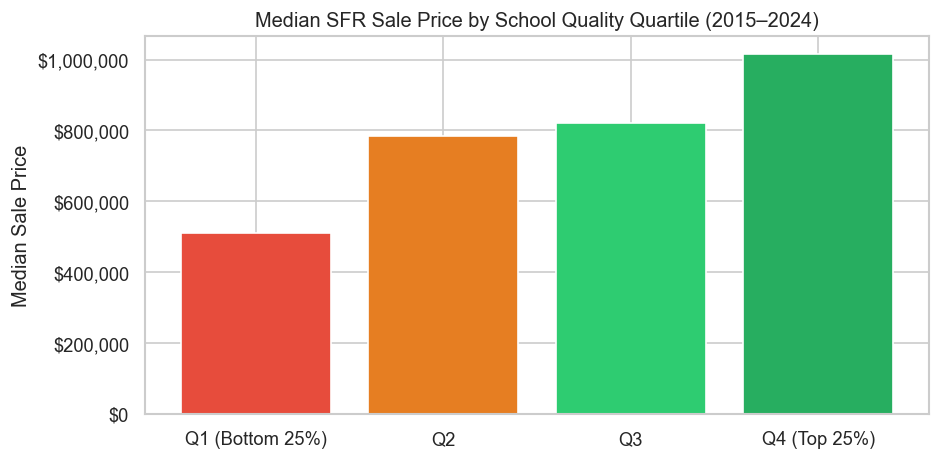


Top-quartile school premium over bottom quartile: +98.6%


In [16]:
# ── School quality quartile analysis ─────────────────────────────────────────
if with_scores['pct_composite'].notna().sum() > 100:
    with_scores['school_quartile'] = pd.qcut(
        with_scores['pct_composite'], q=4,
        labels=['Q1 (Bottom 25%)', 'Q2', 'Q3', 'Q4 (Top 25%)']
    )
    
    quartile_price = with_scores.groupby('school_quartile')['SalePrice'].agg(['median', 'count'])
    print('Median sale price by school quality quartile:')
    print(quartile_price)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(quartile_price.index, quartile_price['median'],
           color=['#e74c3c', '#e67e22', '#2ecc71', '#27ae60'])
    ax.set_title('Median SFR Sale Price by School Quality Quartile (2015–2024)')
    ax.set_ylabel('Median Sale Price')
    ax.yaxis.set_major_formatter(fmt_dol)
    plt.tight_layout()
    plt.show()
    
    q1_med = quartile_price.loc['Q1 (Bottom 25%)', 'median']
    q4_med = quartile_price.loc['Q4 (Top 25%)', 'median']
    premium = (q4_med / q1_med - 1) * 100
    print(f'\nTop-quartile school premium over bottom quartile: {premium:+.1f}%')
else:
    print('Placeholder — complete GIS spatial join to run quartile analysis.')

**Conclusions (to be updated after GIS spatial join is complete):**
- OSPI composite pass rates vary widely across King County districts, providing a meaningful and granular quality signal.
- District-level analysis (once spatial join is complete) is expected to show a positive correlation between school pass rates and median home prices — consistent with the broader literature on school quality premiums.
- The proxy GreatSchools rating (OSPI percentile → 1–10) is available as a stand-in until commercial API access is obtained.
- **Next step:** Complete the GIS spatial join (Section 3) to assign school districts to individual PINs and re-run the quartile and scatter analyses with full property-level data.

---
## 5. Summary & Next Steps

| Status | Item |
|--------|------|
| ✅ Done | OSPI 2023–24 assessment data downloaded and school/district scores computed |
| ✅ Done | Proxy GreatSchools rating (1–10) derived from OSPI percentile rank |
| ⏳ Pending | Install `geopandas` and download KC school district boundary shapefiles |
| ⏳ Pending | Point-in-polygon: assign each housing parcel to its school district |
| ⏳ Pending | Obtain parcel lat/lon (from KC GIS Parcel layer or EXTR_Parcel columns) |
| ⏳ Pending | Re-run Section 4 with full property-level school assignment |
| ⏳ Optional | Obtain GreatSchools API credentials for commercial 1–10 ratings |